# FTSE 350 Financial Services Forecasting

In [1]:
%matplotlib inline

import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Data Preparation

In [2]:
raw_df = pd.read_csv(
    "FTSE 350 Financial Services Historical Data (1).csv"
)

raw_df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,01-07-2026,"15,377.84","15,116.63","15,389.73","15,116.63",NaN,1.73%
1,30-06-2026,"15,116.63","15,030.75","15,210.84","15,012.60",NaN,0.57%
2,29-06-2026,"15,030.75","15,069.79","15,197.09","14,992.53",NaN,-0.26%
3,26-06-2026,"15,069.79","15,134.57","15,175.86","14,905.53",NaN,-0.43%
4,25-06-2026,"15,134.57","14,683.90","15,285.60","14,655.49",NaN,3.07%


In [3]:
data = raw_df.copy()

data["Date"] = pd.to_datetime(
    data["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

for column in ["Price", "Open", "High", "Low"]:
    data[column] = pd.to_numeric(
        data[column].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

data["Change_Percentage"] = pd.to_numeric(
    data["Change %"].astype(str).str.replace("%", "", regex=False),
    errors="coerce"
)

data = (
    data
    .drop(columns=["Vol.", "Change %"])
    .drop_duplicates()
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

data_summary = pd.DataFrame({
    "Measure": [
        "Rows",
        "Columns",
        "Start date",
        "End date",
        "Duplicate rows",
        "Missing values"
    ],
    "Value": [
        len(data),
        data.shape[1],
        data["Date"].min().date(),
        data["Date"].max().date(),
        data.duplicated().sum(),
        data.isna().sum().sum()
    ]
})

display(data_summary)
display(data.head())

,Measure,Value
0,Rows,1640
1,Columns,6
2,Start date,2020-01-02
3,End date,2026-07-01
4,Duplicate rows,0
5,Missing values,0


,Date,Price,Open,High,Low,Change_Percentage
0,2020-01-02,"13,035.4300","12,882.2000","13,072.6100","12,882.2000",1.1900
1,2020-01-03,"12,939.5800","13,035.4300","13,035.4300","12,803.9900",-0.7400
2,2020-01-06,"12,726.8200","12,939.5800","12,943.3200","12,642.3800",-1.6400
3,2020-01-07,"12,668.9200","12,726.8200","12,778.3300","12,634.8100",-0.4500
4,2020-01-08,"12,686.8300","12,668.9200","12,686.8300","12,507.3800",0.1400


In [4]:
display(data.describe().T)

,count,mean,min,25%,50%,75%,max,std
Date,1640,2023-04-01 04:50:38.048780288,2020-01-02 00:00:00,2021-08-15 06:00:00,2023-03-30 12:00:00,2024-11-13 06:00:00,2026-07-01 00:00:00,NaN
Price,"1,640.0000","12,297.7044","7,868.9700","10,636.2525","12,053.1750","13,759.7675","17,281.3000","2,093.8462"
Open,"1,640.0000","12,296.0817","7,868.9700","10,636.2525","12,053.1750","13,753.0750","17,281.3000","2,092.5635"
High,"1,640.0000","12,403.6778","8,101.9100","10,747.4625","12,155.9550","13,865.9200","17,400.8700","2,098.1800"
Low,"1,640.0000","12,188.5908","7,528.3200","10,557.5025","11,951.4600","13,632.9500","17,203.2500","2,089.5351"
Change_Percentage,"1,640.0000",0.0350,-36.7500,-0.7400,0.0750,0.8125,58.2100,2.2584


## Exploratory Analysis

In [5]:
data["Daily_Return"] = data["Price"].pct_change()
data["Log_Return"] = np.log(data["Price"] / data["Price"].shift(1))
data["High_Low_Range"] = data["High"] - data["Low"]
data["Open_Close_Difference"] = data["Price"] - data["Open"]

for window in [20, 50, 100]:
    data[f"MA_{window}"] = data["Price"].rolling(window).mean()

data["Volatility_20"] = (
    data["Daily_Return"].rolling(20).std() * np.sqrt(252)
)

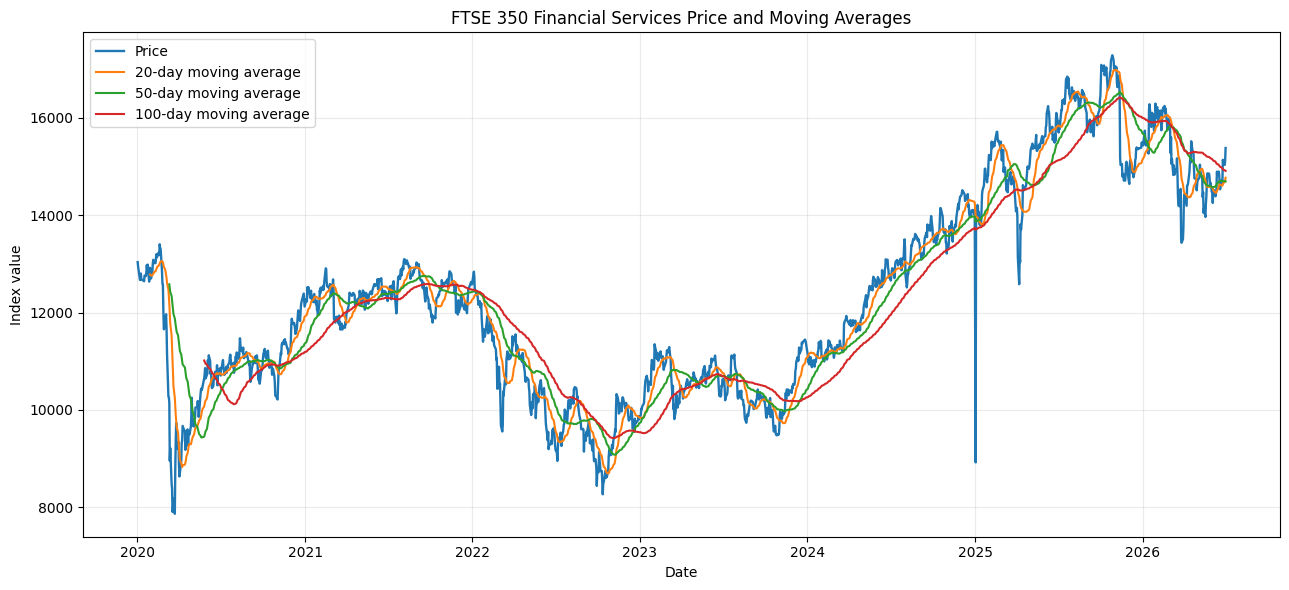

In [6]:
plt.figure(figsize=(13, 6))
plt.plot(data["Date"], data["Price"], label="Price", linewidth=1.7)
plt.plot(data["Date"], data["MA_20"], label="20-day moving average")
plt.plot(data["Date"], data["MA_50"], label="50-day moving average")
plt.plot(data["Date"], data["MA_100"], label="100-day moving average")
plt.title("FTSE 350 Financial Services Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

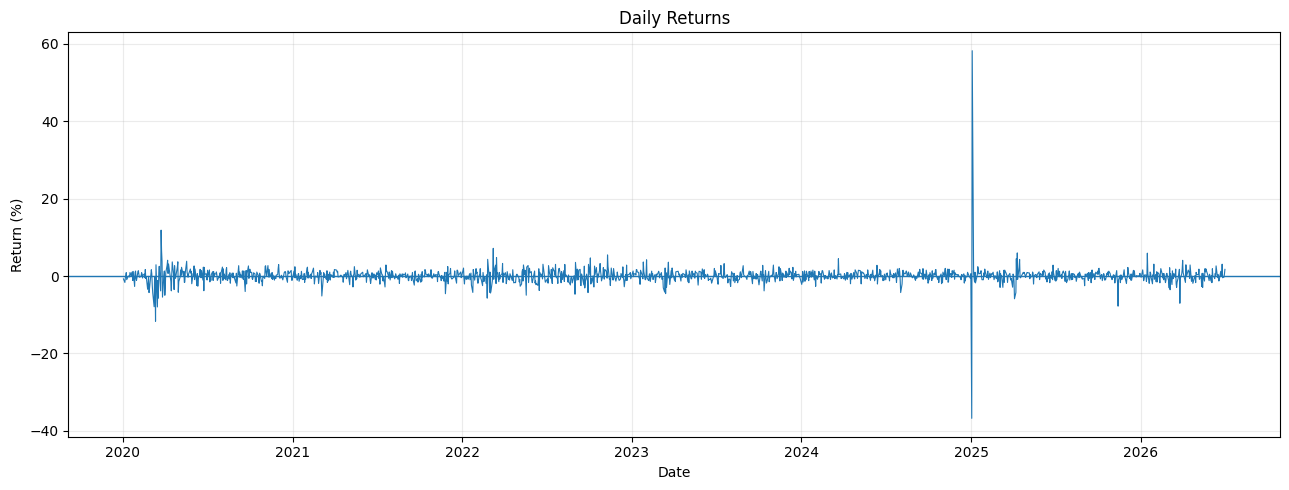

In [7]:
plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Daily_Return"] * 100, linewidth=0.8)
plt.axhline(0, linewidth=1)
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

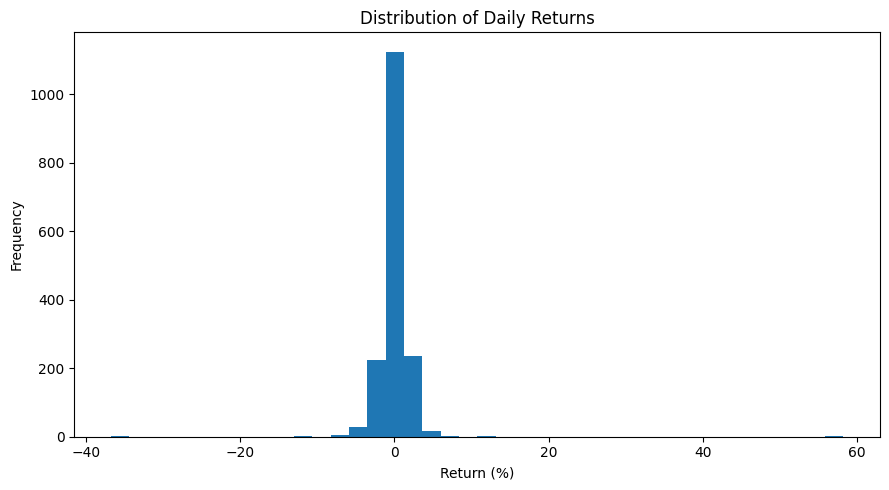

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(data["Daily_Return"].dropna() * 100, bins=40)
plt.title("Distribution of Daily Returns")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

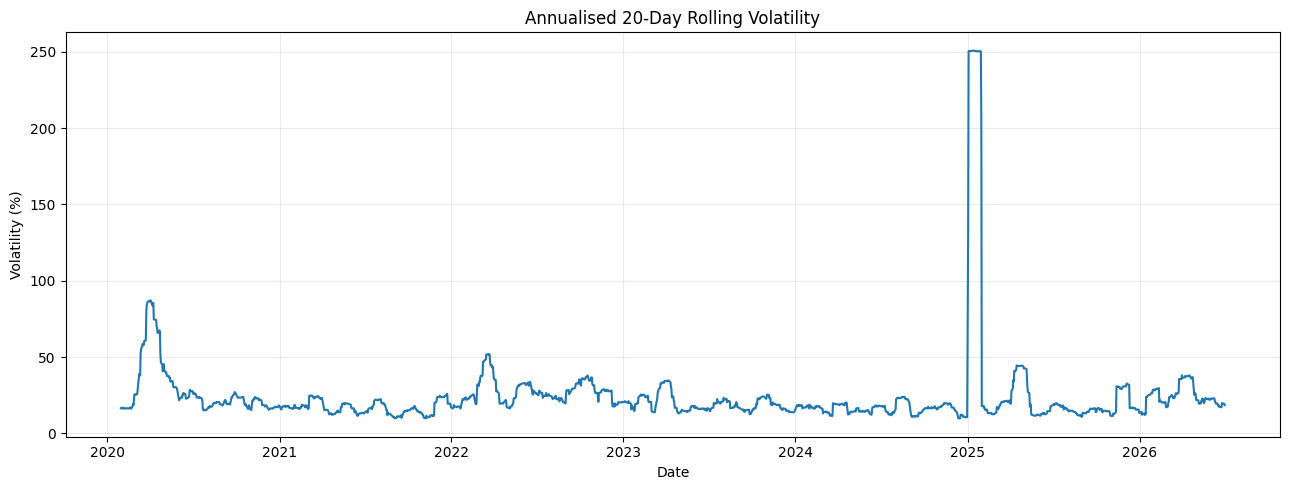

In [9]:
plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volatility_20"] * 100)
plt.title("Annualised 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
yearly = (
    data.assign(Year=data["Date"].dt.year)
    .groupby("Year")
    .agg(
        Start_Price=("Price", "first"),
        End_Price=("Price", "last"),
        Average_Price=("Price", "mean"),
        Return_Volatility=("Daily_Return", "std")
    )
)

yearly["Annual_Return"] = (
    yearly["End_Price"] / yearly["Start_Price"] - 1
) * 100

yearly["Return_Volatility"] = (
    yearly["Return_Volatility"] * np.sqrt(252) * 100
)

display(yearly.round(2))

,Start_Price,End_Price,Average_Price,Return_Volatility,Annual_Return
Year,,,,,
2020,"13,035.4300","12,122.9300","11,048.3800",33.3400,-7.0000
2021,"12,278.2800","12,578.3300","12,403.0900",17.0100,2.4400
2022,"12,838.4300","9,808.0500","10,207.4500",28.7400,-23.6000
2023,"9,896.8900","11,375.8700","10,500.6600",19.8300,14.9400
2024,"11,131.5700","14,110.2900","12,678.5300",16.2500,26.7600
2025,"8,924.5100","15,472.0000","15,532.4000",71.8400,73.3700
2026,"15,430.9300","15,377.8400","15,091.1600",25.4300,-0.3400


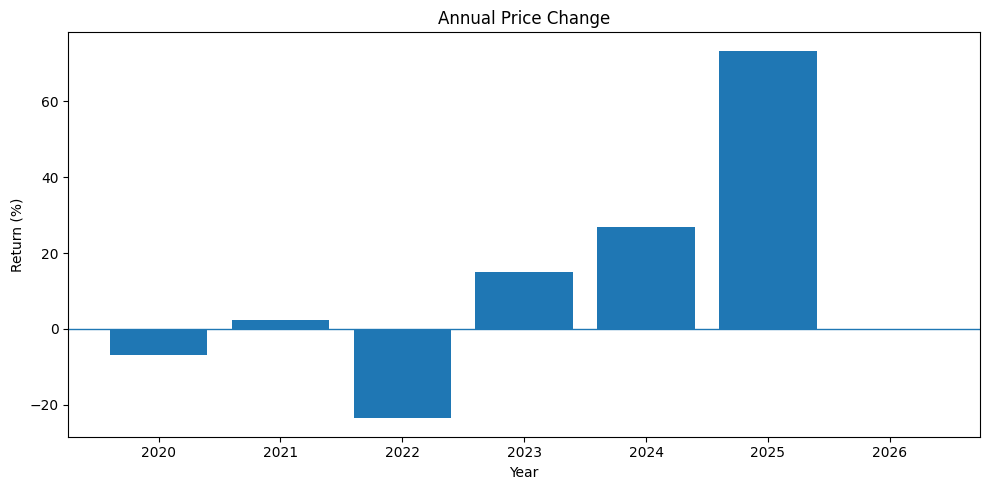

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(yearly.index.astype(str), yearly["Annual_Return"])
plt.axhline(0, linewidth=1)
plt.title("Annual Price Change")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

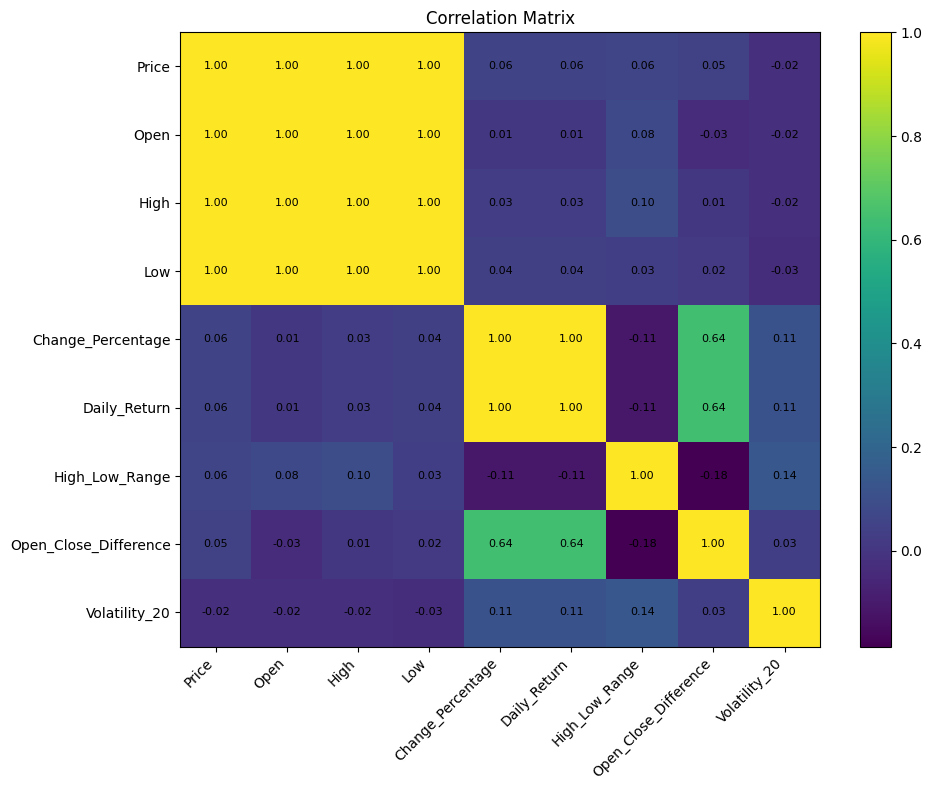

In [12]:
correlation_columns = [
    "Price",
    "Open",
    "High",
    "Low",
    "Change_Percentage",
    "Daily_Return",
    "High_Low_Range",
    "Open_Close_Difference",
    "Volatility_20"
]

correlation = data[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation, aspect="auto")

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        ax.text(
            column,
            row,
            f"{correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(image)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
largest_movements = (
    data[["Date", "Price", "Daily_Return", "High_Low_Range"]]
    .dropna()
    .assign(
        Daily_Return_Percentage=lambda frame: frame["Daily_Return"] * 100,
        Absolute_Return=lambda frame: frame["Daily_Return"].abs()
    )
    .sort_values("Absolute_Return", ascending=False)
    .head(10)
    .drop(columns=["Daily_Return", "Absolute_Return"])
)

display(largest_movements)

,Date,Price,High_Low_Range,Daily_Return_Percentage
1263,2025-01-03,"14,119.7800",70.1100,58.2135
1262,2025-01-02,"8,924.5100",0.0000,-36.7518
58,2020-03-24,"8,802.3900",934.1100,11.8620
50,2020-03-12,"8,957.8300","1,220.0200",-11.6752
52,2020-03-16,"8,483.7900","1,311.1500",-7.9781
47,2020-03-09,"10,273.7800","1,007.8100",-7.9242
1482,2025-11-13,"15,179.5600","1,364.7400",-7.7709
553,2022-03-09,"10,379.2400",694.0300,7.1659
1574,2026-03-26,"13,515.9800","1,061.0400",-7.0233
59,2020-03-25,"9,377.0000",704.1700,6.5279


## Additional Pattern Analysis

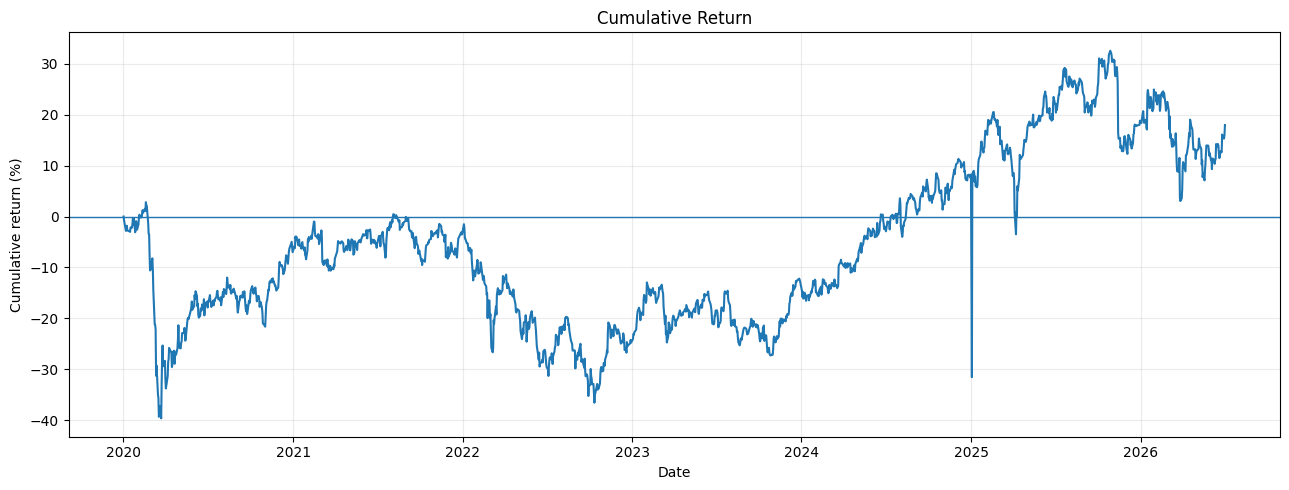

In [14]:
data["Cumulative_Return"] = (
    (1 + data["Daily_Return"].fillna(0)).cumprod() - 1
) * 100

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Cumulative_Return"])
plt.axhline(0, linewidth=1)
plt.title("Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative return (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

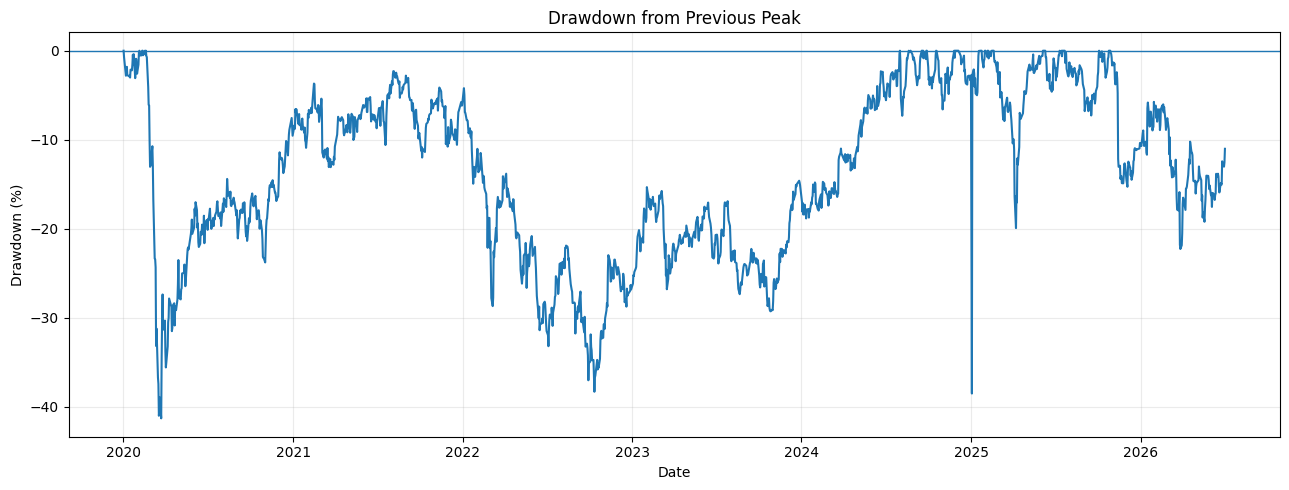

In [15]:
data["Running_Maximum"] = data["Price"].cummax()
data["Drawdown"] = (
    data["Price"] / data["Running_Maximum"] - 1
) * 100

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Drawdown"])
plt.axhline(0, linewidth=1)
plt.title("Drawdown from Previous Peak")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

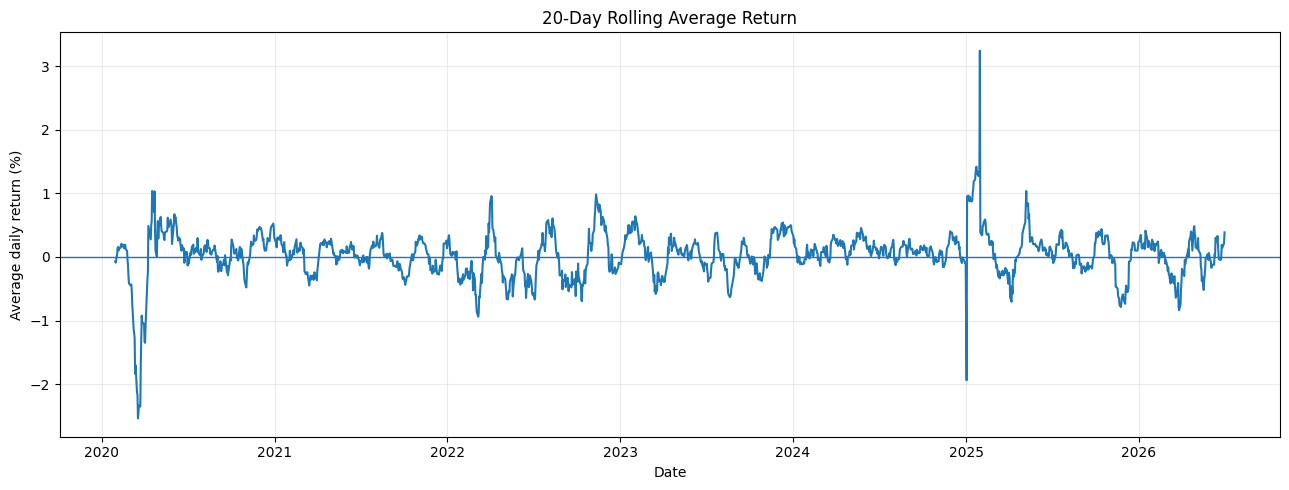

In [16]:
data["Rolling_Return_20"] = (
    data["Daily_Return"].rolling(20).mean() * 100
)

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Rolling_Return_20"])
plt.axhline(0, linewidth=1)
plt.title("20-Day Rolling Average Return")
plt.xlabel("Date")
plt.ylabel("Average daily return (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

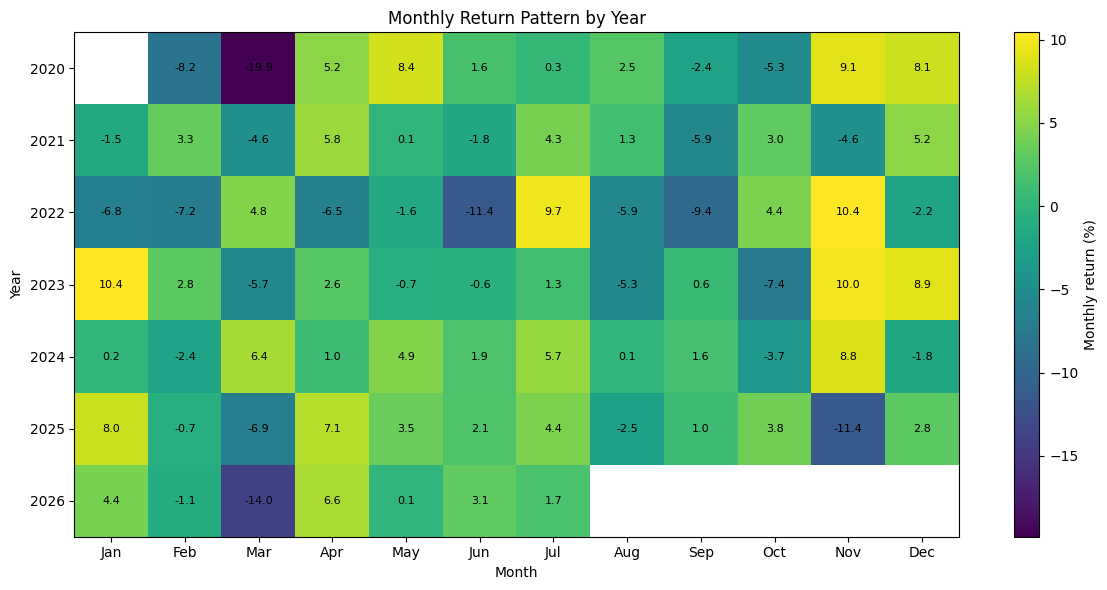

In [17]:
monthly_prices = (
    data.set_index("Date")["Price"]
    .resample("ME")
    .last()
)

monthly_returns = monthly_prices.pct_change() * 100

monthly_pattern = (
    monthly_returns
    .to_frame("Monthly_Return")
    .assign(
        Year=lambda frame: frame.index.year,
        Month=lambda frame: frame.index.month
    )
    .pivot(
        index="Year",
        columns="Month",
        values="Monthly_Return"
    )
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(monthly_pattern, aspect="auto")

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(monthly_pattern.index)))
ax.set_yticklabels(monthly_pattern.index)

for row in range(monthly_pattern.shape[0]):
    for column in range(monthly_pattern.shape[1]):
        value = monthly_pattern.iloc[row, column]
        if pd.notna(value):
            ax.text(
                column,
                row,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=8
            )

fig.colorbar(image, label="Monthly return (%)")
plt.title("Monthly Return Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

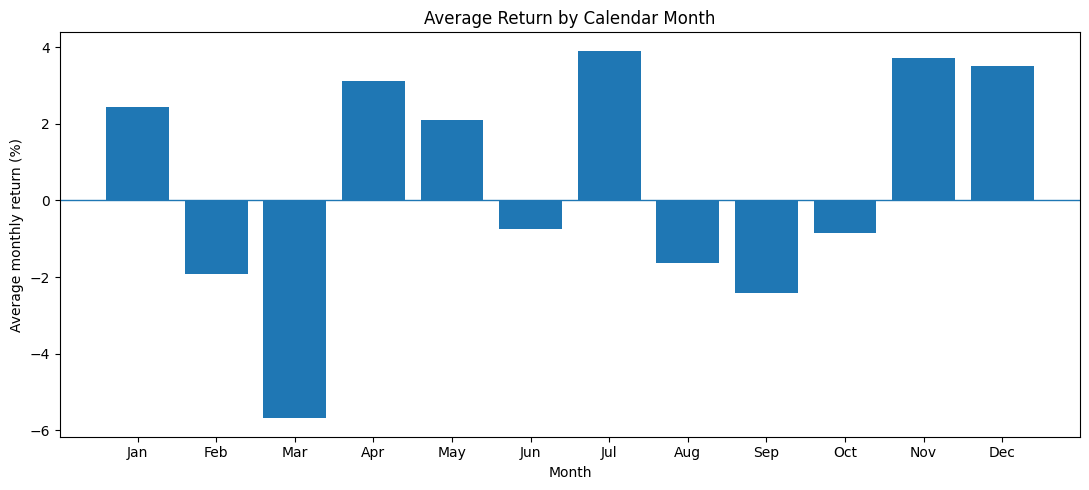

In [18]:
monthly_seasonality = (
    monthly_returns
    .groupby(monthly_returns.index.month)
    .mean()
    .reindex(range(1, 13))
)

plt.figure(figsize=(11, 5))
plt.bar(month_labels, monthly_seasonality)
plt.axhline(0, linewidth=1)
plt.title("Average Return by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average monthly return (%)")
plt.tight_layout()
plt.show()

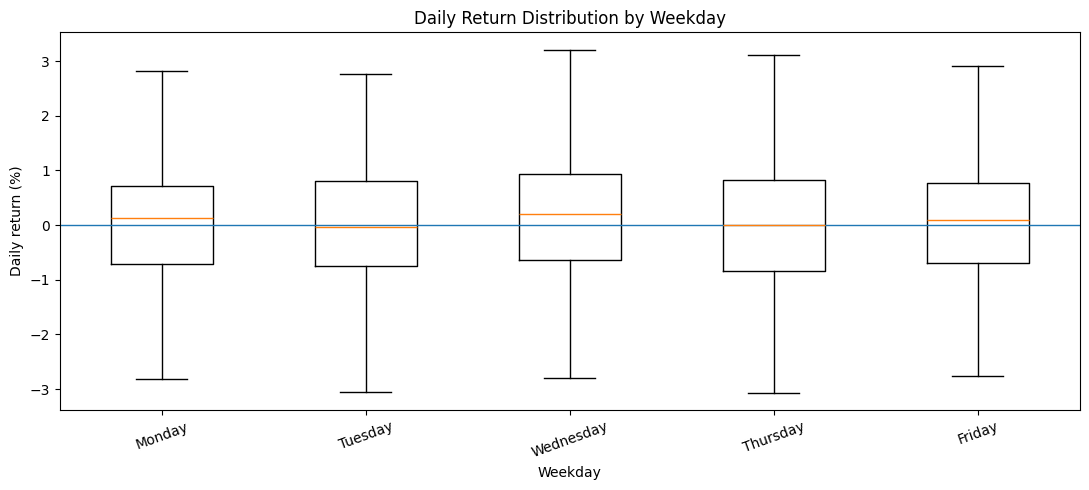

In [19]:
weekday_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday"
]

weekday_returns = [
    data.loc[
        data["Date"].dt.dayofweek == day,
        "Daily_Return"
    ].dropna() * 100
    for day in range(5)
]

plt.figure(figsize=(11, 5))
plt.boxplot(
    weekday_returns,
    tick_labels=weekday_names,
    showfliers=False
)
plt.axhline(0, linewidth=1)
plt.title("Daily Return Distribution by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Daily return (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

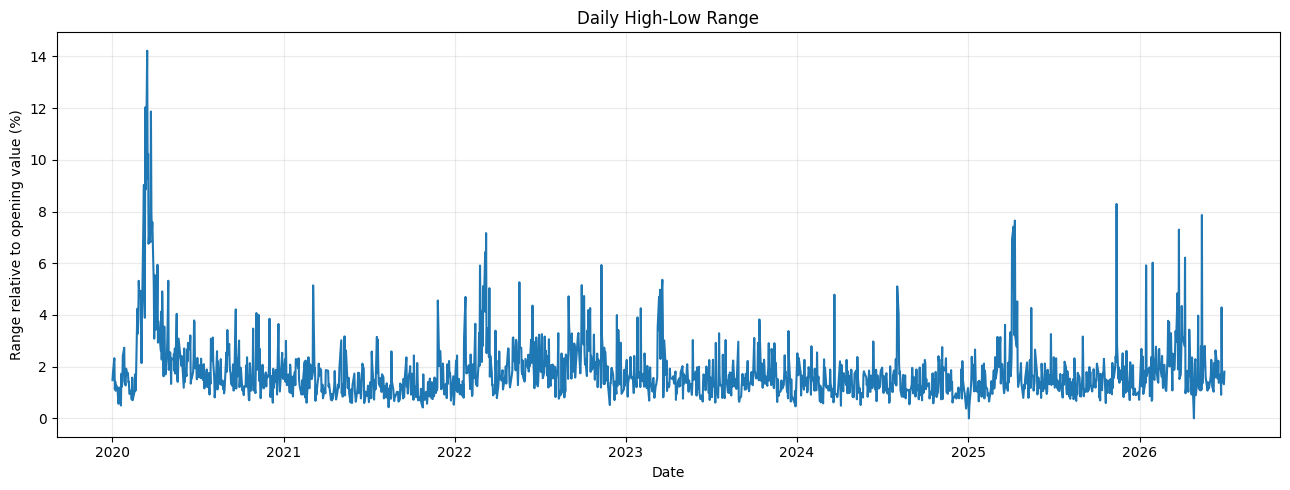

In [20]:
data["Range_Percentage"] = (
    (data["High"] - data["Low"]) / data["Open"]
) * 100

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Range_Percentage"])
plt.title("Daily High-Low Range")
plt.xlabel("Date")
plt.ylabel("Range relative to opening value (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

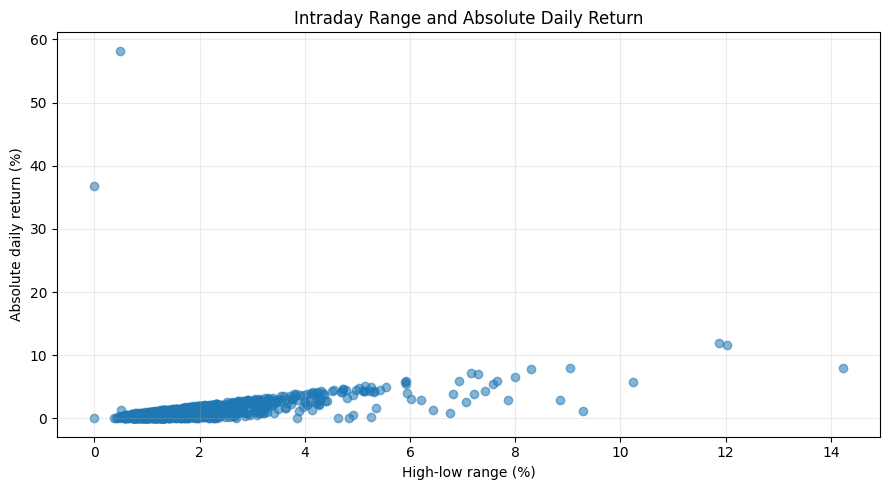

In [21]:
plt.figure(figsize=(9, 5))
plt.scatter(
    data["Range_Percentage"],
    data["Daily_Return"].abs() * 100,
    alpha=0.55
)
plt.title("Intraday Range and Absolute Daily Return")
plt.xlabel("High-low range (%)")
plt.ylabel("Absolute daily return (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

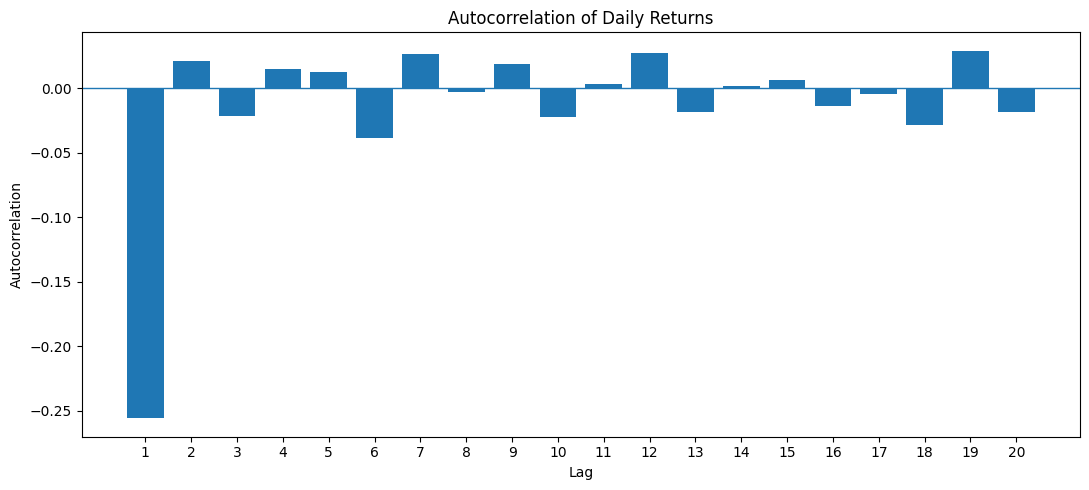

In [22]:
return_series = data["Daily_Return"].dropna()

return_autocorrelation = pd.Series(
    {
        lag: return_series.autocorr(lag=lag)
        for lag in range(1, 21)
    }
)

plt.figure(figsize=(11, 5))
plt.bar(
    return_autocorrelation.index,
    return_autocorrelation.values
)
plt.axhline(0, linewidth=1)
plt.title("Autocorrelation of Daily Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

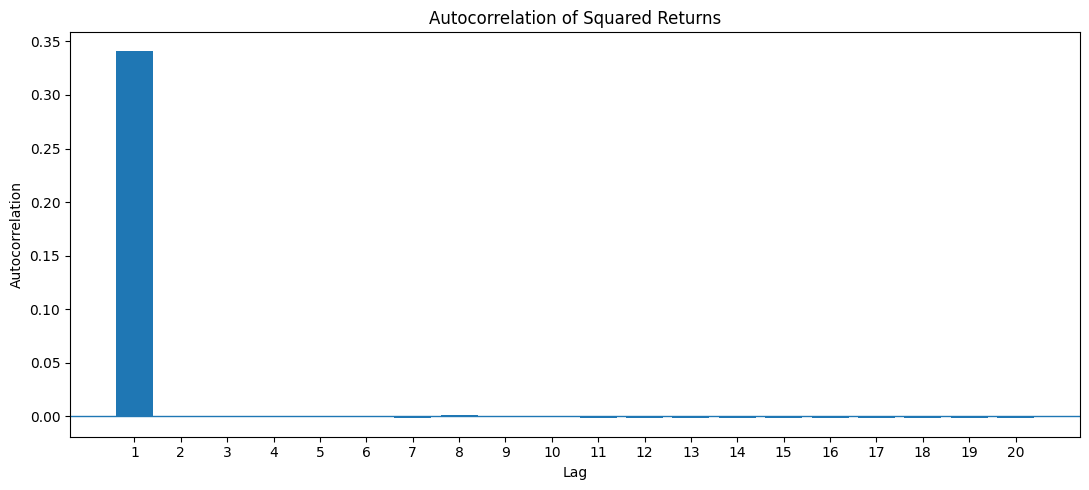

In [23]:
squared_returns = return_series ** 2

volatility_autocorrelation = pd.Series(
    {
        lag: squared_returns.autocorr(lag=lag)
        for lag in range(1, 21)
    }
)

plt.figure(figsize=(11, 5))
plt.bar(
    volatility_autocorrelation.index,
    volatility_autocorrelation.values
)
plt.axhline(0, linewidth=1)
plt.title("Autocorrelation of Squared Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

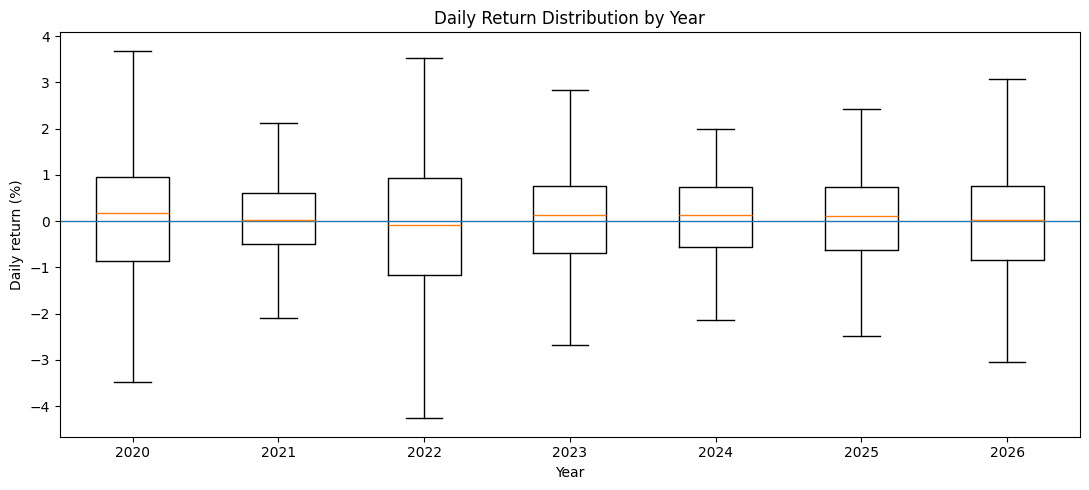

In [24]:
yearly_return_groups = [
    group["Daily_Return"].dropna() * 100
    for _, group in data.groupby(data["Date"].dt.year)
]

year_labels = [
    str(year)
    for year in sorted(data["Date"].dt.year.unique())
]

plt.figure(figsize=(11, 5))
plt.boxplot(
    yearly_return_groups,
    tick_labels=year_labels,
    showfliers=False
)
plt.axhline(0, linewidth=1)
plt.title("Daily Return Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Daily return (%)")
plt.tight_layout()
plt.show()

In [25]:
pattern_summary = pd.DataFrame({
    "Measure": [
        "Highest cumulative return (%)",
        "Maximum drawdown (%)",
        "Highest annualised volatility (%)",
        "Average daily range (%)",
        "Return-range correlation",
        "Lag-1 return autocorrelation",
        "Lag-1 squared-return autocorrelation"
    ],
    "Value": [
        data["Cumulative_Return"].max(),
        data["Drawdown"].min(),
        data["Volatility_20"].max() * 100,
        data["Range_Percentage"].mean(),
        data[
            ["Range_Percentage", "Daily_Return"]
        ].assign(
            Absolute_Return=lambda frame: frame["Daily_Return"].abs()
        )[["Range_Percentage", "Absolute_Return"]].corr().iloc[0, 1],
        return_autocorrelation.loc[1],
        volatility_autocorrelation.loc[1]
    ]
})

display(pattern_summary.round(4))

,Measure,Value
0,Highest cumulative return (%),32.5718
1,Maximum drawdown (%),-41.2867
2,Highest annualised volatility (%),250.7202
3,Average daily range (%),1.7932
4,Return-range correlation,0.4138
5,Lag-1 return autocorrelation,-0.2558
6,Lag-1 squared-return autocorrelation,0.3414


## Model Development and Performance Evaluation



## 3. Common Feature Engineering and Experimental Conditions

In [26]:
data["Daily_Return"] = data["Price"].pct_change()
data["High_Low_Range"] = data["High"] - data["Low"]
data["Open_Close_Difference"] = data["Price"] - data["Open"]
data["Price_MA_5"] = data["Price"].rolling(5).mean()
data["Price_MA_10"] = data["Price"].rolling(10).mean()
data["Volatility_10"] = data["Daily_Return"].rolling(10).std()
data["Target_Price"] = data["Price"].shift(-1)
data["Target_Change"] = data["Target_Price"] - data["Price"]

feature_columns = [
    "Price",
    "Open",
    "High",
    "Low",
    "Change_Percentage",
    "Daily_Return",
    "High_Low_Range",
    "Open_Close_Difference",
    "Price_MA_5",
    "Price_MA_10",
    "Volatility_10"
]

model_data = (
    data[["Date", "Target_Price", "Target_Change"] + feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

LOOKBACK = 20
n_rows = len(model_data)
train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(model_data.iloc[:train_end][feature_columns])
target_scaler.fit(model_data.iloc[:train_end][["Target_Change"]])

scaled_features = feature_scaler.transform(model_data[feature_columns])
scaled_target = target_scaler.transform(model_data[["Target_Change"]]).reshape(-1)

X_sequences = []
y_sequences = []
target_indices = []

for index in range(LOOKBACK - 1, len(model_data)):
    X_sequences.append(scaled_features[index - LOOKBACK + 1:index + 1])
    y_sequences.append(scaled_target[index])
    target_indices.append(index)

X_sequences = np.asarray(X_sequences, dtype=np.float32)
y_sequences = np.asarray(y_sequences, dtype=np.float32)
target_indices = np.asarray(target_indices)

train_mask = target_indices < train_end
validation_mask = (target_indices >= train_end) & (target_indices < validation_end)
test_mask = target_indices >= validation_end

X_train_sequence = X_sequences[train_mask]
X_validation_sequence = X_sequences[validation_mask]
X_test_sequence = X_sequences[test_mask]

y_train_scaled = y_sequences[train_mask]
y_validation_scaled = y_sequences[validation_mask]
y_test_scaled = y_sequences[test_mask]

X_train_flat = X_train_sequence.reshape(len(X_train_sequence), -1)
X_validation_flat = X_validation_sequence.reshape(len(X_validation_sequence), -1)
X_test_flat = X_test_sequence.reshape(len(X_test_sequence), -1)

validation_rows = model_data.iloc[target_indices[validation_mask]].reset_index(drop=True)
test_rows = model_data.iloc[target_indices[test_mask]].reset_index(drop=True)

split_summary = pd.DataFrame({
    "Set": ["Training", "Validation", "Test"],
    "Observations": [train_mask.sum(), validation_mask.sum(), test_mask.sum()],
    "Start": [
        model_data.iloc[target_indices[train_mask]]["Date"].min().date(),
        validation_rows["Date"].min().date(),
        test_rows["Date"].min().date()
    ],
    "End": [
        model_data.iloc[target_indices[train_mask]]["Date"].max().date(),
        validation_rows["Date"].max().date(),
        test_rows["Date"].max().date()
    ]
})

conditions = pd.DataFrame({
    "Condition": [
        "Forecast target",
        "Lookback window",
        "Data split",
        "Feature scaling",
        "Target scaling",
        "Random seed",
        "Evaluation metrics"
    ],
    "Applied equally to all models": [
        "Next-day index price change",
        "20 trading days",
        "70% training, 15% validation, 15% test in chronological order",
        "StandardScaler fitted only on training data",
        "StandardScaler fitted only on training data",
        RANDOM_STATE,
        "MAE, RMSE, Price R², Change R² and directional accuracy"
    ]
})

display(conditions)
display(split_summary)
print("Sequence shape:", X_sequences.shape)

,Condition,Applied equally to all models
0,Forecast target,Next-day index price change
1,Lookback window,20 trading days
2,Data split,"70% training, 15% validation, 15% test in chro..."
3,Feature scaling,StandardScaler fitted only on training data
4,Target scaling,StandardScaler fitted only on training data
5,Random seed,42
6,Evaluation metrics,"MAE, RMSE, Price R², Change R² and directional..."


,Set,Observations,Start,End
0,Training,1121,2020-02-12,2024-07-23
1,Validation,244,2024-07-24,2025-07-10
2,Test,245,2025-07-11,2026-06-30


Sequence shape: (1610, 20, 11)


## 4. Common Performance Evaluation

In [27]:
model_results = []


def inverse_target(values):
    return target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).reshape(-1)


def calculate_metrics(frame, predicted_change):
    actual_change = frame["Target_Change"].to_numpy()
    actual_price = frame["Target_Price"].to_numpy()
    predicted_change = np.asarray(predicted_change).reshape(-1)
    predicted_price = frame["Price"].to_numpy() + predicted_change

    return {
        "MAE": mean_absolute_error(actual_price, predicted_price),
        "RMSE": np.sqrt(mean_squared_error(actual_price, predicted_price)),
        "Price_R2": r2_score(actual_price, predicted_price),
        "Change_R2": r2_score(actual_change, predicted_change),
        "Directional_Accuracy": (
            np.sign(actual_change) == np.sign(predicted_change)
        ).mean() * 100
    }


def evaluate_model(model_name, validation_prediction_scaled, test_prediction_scaled):
    validation_prediction = inverse_target(validation_prediction_scaled)
    test_prediction = inverse_target(test_prediction_scaled)

    validation_metrics = calculate_metrics(validation_rows, validation_prediction)
    test_metrics = calculate_metrics(test_rows, test_prediction)

    performance = pd.DataFrame([
        {"Set": "Validation", **validation_metrics},
        {"Set": "Test", **test_metrics}
    ])

    display(performance.round(4))

    actual_price = test_rows["Target_Price"].to_numpy()
    predicted_price = test_rows["Price"].to_numpy() + test_prediction

    plt.figure(figsize=(12, 5))
    plt.plot(test_rows["Date"], actual_price, label="Actual next-day price")
    plt.plot(test_rows["Date"], predicted_price, label="Predicted next-day price")
    plt.title(f"{model_name} Test Performance")
    plt.xlabel("Date")
    plt.ylabel("FTSE 350 Financial Services Index")
    plt.legend()
    plt.tight_layout()
    plt.show()

    model_results.append({"Model": model_name, **test_metrics})

## 5. Model 1 Linear Regression

,Set,MAE,RMSE,Price_R2,Change_R2,Directional_Accuracy
0,Validation,773.2098,"2,690.6595",-6.3049,-27.7312,47.1311
1,Test,200.2350,263.6887,0.9091,-0.5087,51.8367


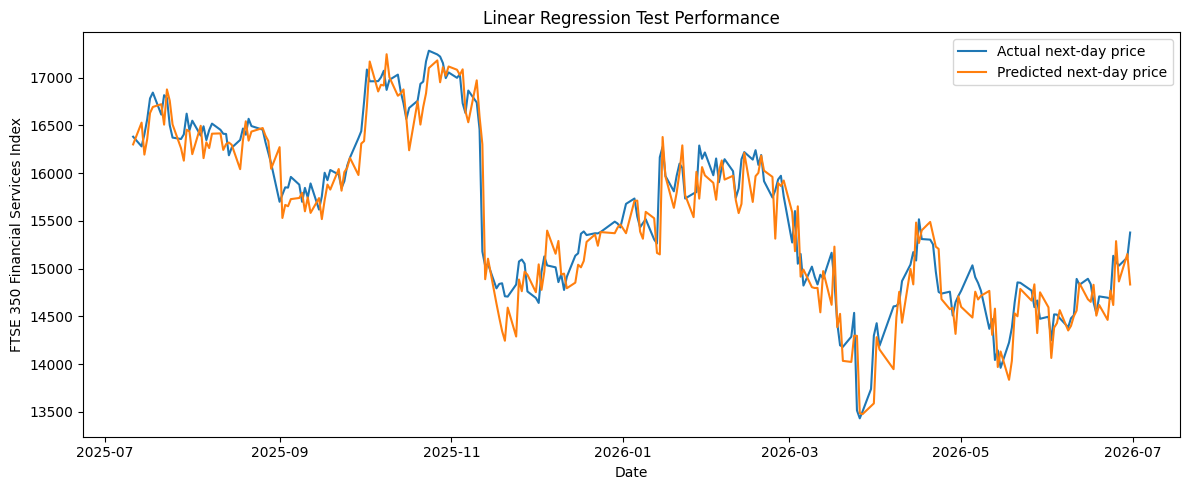

In [28]:
linear_regression = LinearRegression()
linear_regression.fit(X_train_flat, y_train_scaled)

linear_validation_prediction = linear_regression.predict(X_validation_flat)
linear_test_prediction = linear_regression.predict(X_test_flat)

evaluate_model(
    "Linear Regression",
    linear_validation_prediction,
    linear_test_prediction
)

## 6. Model 2 Random Forest

,Set,MAE,RMSE,Price_R2,Change_R2,Directional_Accuracy
0,Validation,667.2072,818.1146,0.3247,-1.6562,45.0820
1,Test,690.6030,715.8021,0.3300,-10.1173,48.9796


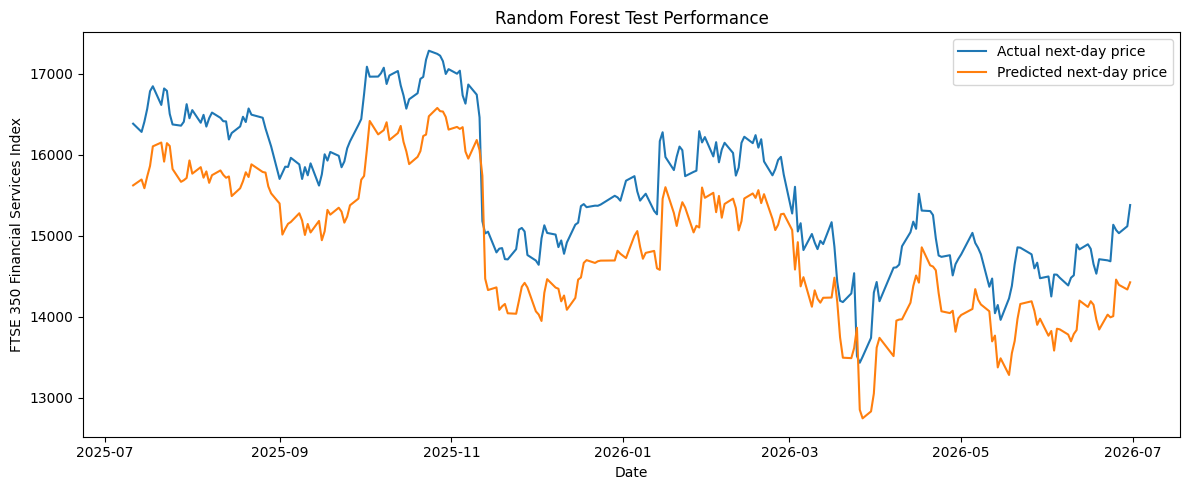

In [29]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest.fit(X_train_flat, y_train_scaled)

random_forest_validation_prediction = random_forest.predict(X_validation_flat)
random_forest_test_prediction = random_forest.predict(X_test_flat)

evaluate_model(
    "Random Forest",
    random_forest_validation_prediction,
    random_forest_test_prediction
)

## 7. Model 3 XGBoost

,Set,MAE,RMSE,Price_R2,Change_R2,Directional_Accuracy
0,Validation,438.6224,640.9704,0.5855,-0.6305,45.0820
1,Test,406.4840,453.8282,0.7307,-3.4689,48.9796


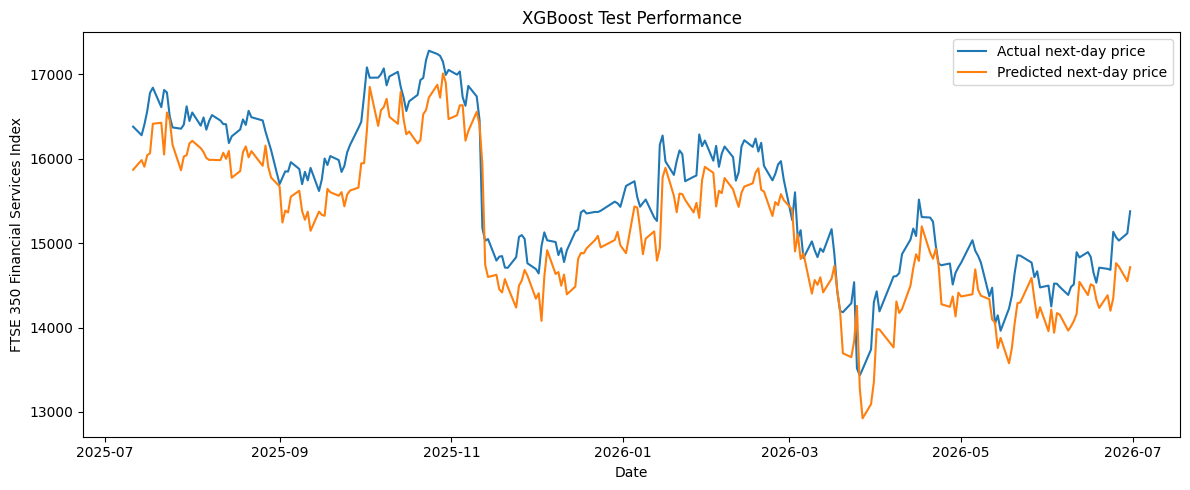

In [30]:
xgboost_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgboost_model.fit(X_train_flat, y_train_scaled)

xgboost_validation_prediction = xgboost_model.predict(X_validation_flat)
xgboost_test_prediction = xgboost_model.predict(X_test_flat)

evaluate_model(
    "XGBoost",
    xgboost_validation_prediction,
    xgboost_test_prediction
)

## 8. Model 4 LSTM

,Set,MAE,RMSE,Price_R2,Change_R2,Directional_Accuracy
0,Validation,297.2699,551.0873,0.6936,-0.2053,45.0820
1,Test,264.7272,318.5417,0.8673,-1.2016,48.9796


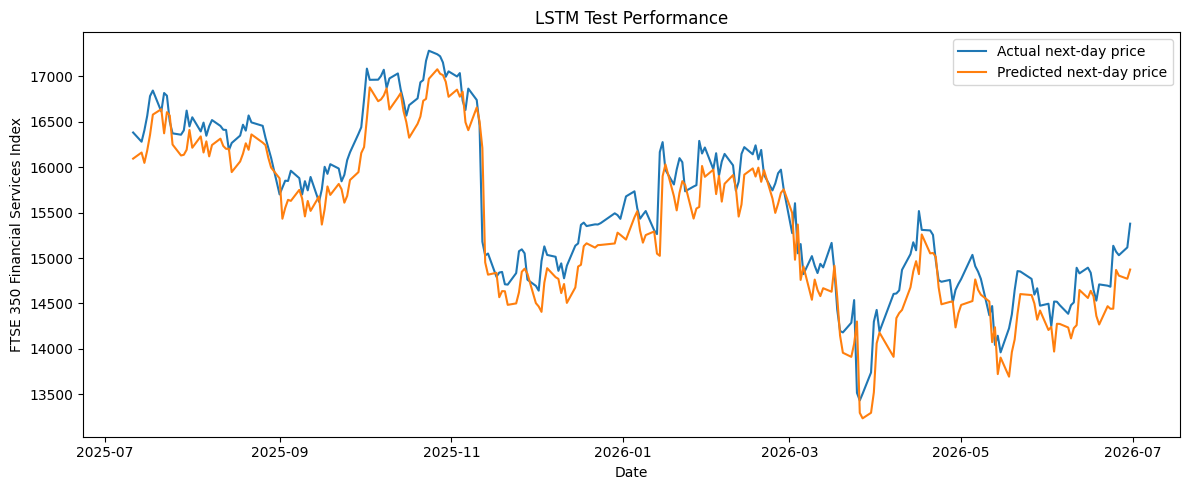

In [31]:
class LSTMRegressor(nn.Module):
    def __init__(self, number_of_features):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=number_of_features,
            hidden_size=32,
            num_layers=1,
            batch_first=True
        )
        self.output = nn.Linear(32, 1)

    def forward(self, values):
        sequence_output, _ = self.lstm(values)
        return self.output(sequence_output[:, -1, :]).squeeze(1)


torch.manual_seed(RANDOM_STATE)
lstm_model = LSTMRegressor(X_train_sequence.shape[2])
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

training_dataset = TensorDataset(
    torch.tensor(X_train_sequence, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32)
)

training_loader = DataLoader(
    training_dataset,
    batch_size=32,
    shuffle=False
)

EPOCHS = 50

for epoch in range(EPOCHS):
    lstm_model.train()
    for batch_features, batch_target in training_loader:
        optimizer.zero_grad()
        batch_prediction = lstm_model(batch_features)
        loss = loss_function(batch_prediction, batch_target)
        loss.backward()
        optimizer.step()

lstm_model.eval()

with torch.no_grad():
    lstm_validation_prediction = lstm_model(
        torch.tensor(X_validation_sequence, dtype=torch.float32)
    ).numpy()

    lstm_test_prediction = lstm_model(
        torch.tensor(X_test_sequence, dtype=torch.float32)
    ).numpy()

evaluate_model(
    "LSTM",
    lstm_validation_prediction,
    lstm_test_prediction
)

## 9. Final Model Comparison

,Rank,Model,MAE,RMSE,Price_R2,Change_R2,Directional_Accuracy
0,1,Linear Regression,200.2350,263.6887,0.9091,-0.5087,51.8367
1,2,LSTM,264.7272,318.5417,0.8673,-1.2016,48.9796
2,3,XGBoost,406.4840,453.8282,0.7307,-3.4689,48.9796
3,4,Random Forest,690.6030,715.8021,0.3300,-10.1173,48.9796


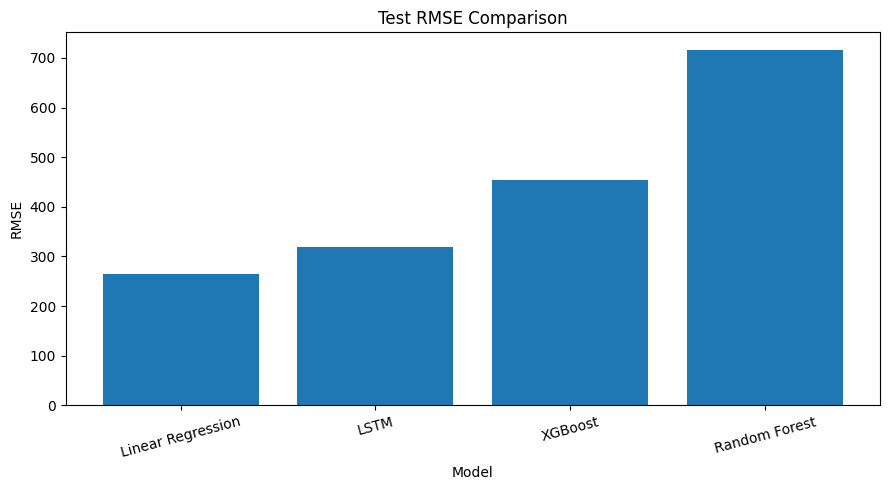

Best model by test RMSE: Linear Regression with RMSE 263.69.


In [32]:
comparison = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparison.insert(0, "Rank", np.arange(1, len(comparison) + 1))
comparison = comparison[[
    "Rank",
    "Model",
    "MAE",
    "RMSE",
    "Price_R2",
    "Change_R2",
    "Directional_Accuracy"
]]

display(comparison.round(4))

plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.title("Test RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

comparison.to_csv("FTSE_Simplified_Model_Comparison.csv", index=False)

best_model = comparison.iloc[0]
print(
    f"Best model by test RMSE: {best_model['Model']} "
    f"with RMSE {best_model['RMSE']:.2f}."
)